# Pregunta 2
## ¿Existe una relación entre la desigualdad socioeconomíca y el rendimiento escolar?

## Avance del proyecto .




### 1. Contexto de las bases de datos.

Para responder a esta pregunta se busca estudiar si existe una relación entre la desigualdad socioeconómica y el rendimiento escolar en establecimiento educacioanles en Chile.
Para esto trabajaremos con 2 datasets del año 2024. ambas a nivel RBD (establecimiento), lo cual permite relacioanrlos directamente.

La primera corresponde al Simce de segundos medio del año 2024 y contiene infomacion sobre el rendimiento academico de los establecimientos de las pruebas de lectura y matemática. La segunda corresponde a Idps 2024, que incluye indicadores de desarrollo personal y social, como autoestima académica, convivencia escolar , hábitos de vida saludablre y participacion ciudadana.

### 2. Imports.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# estilo general de los gráficos
sns.set(style="whitegrid")

# tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (8, 5)

### 3. Carga de las bases de datos.

In [3]:
# cargar base SIMCE
simce = pd.read_csv("simce2m2024_rbd_preliminar.csv", sep=";", encoding="latin1")

# cargar base IDPS
idps = pd.read_csv("idps2M2024_rbd_preliminar.csv", sep=";", encoding="latin1")

### 4. Revisión preliminar de los datasets.

In [4]:
# ver cantidad de filas y columnas de cada dataset
print("SIMCE:", simce.shape)
print("IDPS:", idps.shape)

SIMCE: (3000, 42)
IDPS: (12000, 22)


### 4.1 Columnas disponibles.

In [5]:
# mostrar nombres de columnas de SIMCE
print(simce.columns.tolist())

# mostrar nombres de columnas de IDPS
print(idps.columns.tolist())

['rbd', 'dvrbd', 'nom_rbd', 'cod_reg_rbd', 'nom_reg_rbd', 'cod_pro_rbd', 'nom_pro_rbd', 'cod_com_rbd', 'nom_com_rbd', 'cod_deprov_rbd', 'nom_deprov_rbd', 'cod_depe1', 'cod_depe2', 'cod_grupo', 'cod_rural_rbd', 'nalu_lect2m_rbd', 'nalu_mate2m_rbd', 'prom_lect2m_rbd', 'prom_mate2m_rbd', 'dif_lect2m_rbd', 'dif_mate2m_rbd', 'difgru_lect2m_rbd', 'difgru_mate2m_rbd', 'sigdif_lect2m_rbd', 'sigdif_mate2m_rbd', 'siggru_lect2m_rbd', 'siggru_mate2m_rbd', 'marca_lect2m_rbd', 'marca_mate2m_rbd', 'marcadif_lect2m_rbd', 'marcadif_mate2m_rbd', 'palu_eda_ins_lect2m_rbd', 'palu_eda_ele_lect2m_rbd', 'palu_eda_ade_lect2m_rbd', 'palu_eda_ins_mate2m_rbd', 'palu_eda_ele_mate2m_rbd', 'palu_eda_ade_mate2m_rbd', 'noaplica', 'codigo_bbdd', 'fecha_bbdd', 'grado', 'agno']
['agno', 'rbd', 'ind', 'prom', 'dif', 'sigdif', 'difgru', 'sigdifgru', 'nom_rbd', 'cod_reg_rbd', 'nom_reg_rbd', 'cod_pro_rbd', 'nom_pro_rbd', 'cod_com_rbd', 'nom_com_rbd', 'nom_deprov_rbd', 'cod_depe2', 'cod_grupo', 'cod_rural_rbd', 'codigo_bdd',

### 4.2 Primeras Filas.

In [8]:
# primeras filas de la base SIMCE
simce.head()

,rbd,dvrbd,nom_rbd,cod_reg_rbd,nom_reg_rbd,cod_pro_rbd,nom_pro_rbd,cod_com_rbd,nom_com_rbd,cod_deprov_rbd,...,palu_eda_ele_lect2m_rbd,palu_eda_ade_lect2m_rbd,palu_eda_ins_mate2m_rbd,palu_eda_ele_mate2m_rbd,palu_eda_ade_mate2m_rbd,noaplica,codigo_bbdd,fecha_bbdd,grado,agno
0,7826,3,COLEGIO SAN MIGUEL,10,DE LOS LAGOS,101,LLANQUIHUE,10102,CALBUCO,101,...,31.0,12.0,62.3,29.2,8.5,0,preliminar20240422v1,20250422,2m,2024
1,6830,6,COLEGIO NUESTRA SENORA DEL CARMEN,14,DE LOS RÍOS,141,VALDIVIA,14101,VALDIVIA,141,...,31.0,23.9,66.7,24.4,9.0,0,preliminar20240422v1,20250422,2m,2024
2,40126,9,COLEGIO RAUL SILVA HENRIQUEZ,4,DE COQUIMBO,43,LIMARÍ,4301,OVALLE,42,...,26.9,9.0,71.6,22.4,6.0,0,preliminar20240422v1,20250422,2m,2024
3,18237,0,COLEGIO AMANECER SAN CARLOS,8,DEL BIOBÍO,81,CONCEPCIÓN,8108,SAN PEDRO DE LA PAZ,83,...,23.8,23.8,46.4,27.4,26.2,0,preliminar20240422v1,20250422,2m,2024
4,14324,3,COLEGIO WILLIAM JAMES,5,DE VALPARAÍSO,51,VALPARAÍSO,5109,VIÑA DEL MAR,53,...,0.0,0.0,45.5,45.5,9.1,0,preliminar20240422v1,20250422,2m,2024


In [7]:
# primeras filas de la base IDPS
idps.head()

,agno,rbd,ind,prom,dif,sigdif,difgru,sigdifgru,nom_rbd,cod_reg_rbd,...,nom_pro_rbd,cod_com_rbd,nom_com_rbd,nom_deprov_rbd,cod_depe2,cod_grupo,cod_rural_rbd,codigo_bdd,fecha_bbdd,grado
0,2024,1,AM,74.0,0.0,0.0,0.0,0.0,LICEO POLITECNICO ARICA,15,...,ARICA,15101,ARICA,Arica,4,1.0,1,preliminar20240422v1,20250422,2m
1,2024,1,CC,75.0,3.0,0.0,0.0,0.0,LICEO POLITECNICO ARICA,15,...,ARICA,15101,ARICA,Arica,4,1.0,1,preliminar20240422v1,20250422,2m
2,2024,1,HV,74.0,0.0,0.0,2.0,0.0,LICEO POLITECNICO ARICA,15,...,ARICA,15101,ARICA,Arica,4,1.0,1,preliminar20240422v1,20250422,2m
3,2024,1,PF,79.0,3.0,0.0,3.0,0.0,LICEO POLITECNICO ARICA,15,...,ARICA,15101,ARICA,Arica,4,1.0,1,preliminar20240422v1,20250422,2m
4,2024,4,AM,74.0,-2.0,0.0,1.0,0.0,LICEO OCTAVIO PALMA PEREZ,15,...,ARICA,15101,ARICA,Arica,4,3.0,1,preliminar20240422v1,20250422,2m


### 4.3 Crear Diccionarios para traducir categorías.

In [9]:
# nombres más claros para el grupo socioeconómico
gse_map = {
    1: "Bajo",
    2: "Medio bajo",
    3: "Medio",
    4: "Medio alto",
    5: "Alto"
}

# nombres más claros para la dependencia
dep_map = {
    1: "Municipal",
    2: "Particular subvencionado",
    3: "Particular pagado",
    4: "SLEP"
}

# nombres más claros para ruralidad
rural_map = {
    1: "Urbano",
    2: "Rural"
}

Aplicación de traducciónes a simce.

In [10]:
# crear columna con nombre del grupo socioeconómico
simce["gse"] = simce["cod_grupo"].map(gse_map)

# crear columna con nombre de la dependencia
simce["dependencia"] = simce["cod_depe2"].map(dep_map)

# crear columna con nombre de la ruralidad
simce["ruralidad"] = simce["cod_rural_rbd"].map(rural_map)

Aplicación de Traducciónes IDPS.

In [11]:
# crear columna con nombre del grupo socioeconómico
idps["gse"] = idps["cod_grupo"].map(gse_map)

# crear columna con nombre de la dependencia
idps["dependencia"] = idps["cod_depe2"].map(dep_map)

# crear columna con nombre de la ruralidad
idps["ruralidad"] = idps["cod_rural_rbd"].map(rural_map)

### 4.4 Revisión de nulos.

In [14]:
# contar valores faltantes en SIMCE
simce.isnull().sum()

rbd                           0
dvrbd                         0
nom_rbd                       0
cod_reg_rbd                   0
nom_reg_rbd                   0
cod_pro_rbd                   0
nom_pro_rbd                   0
cod_com_rbd                   0
nom_com_rbd                   0
cod_deprov_rbd                0
nom_deprov_rbd                0
cod_depe1                     0
cod_depe2                     0
cod_grupo                     5
cod_rural_rbd                 0
nalu_lect2m_rbd               0
nalu_mate2m_rbd               0
prom_lect2m_rbd               7
prom_mate2m_rbd               6
dif_lect2m_rbd              184
dif_mate2m_rbd              212
difgru_lect2m_rbd            93
difgru_mate2m_rbd           117
sigdif_lect2m_rbd           184
sigdif_mate2m_rbd           212
siggru_lect2m_rbd            93
siggru_mate2m_rbd           117
marca_lect2m_rbd           2923
marca_mate2m_rbd           2903
marcadif_lect2m_rbd        2821
marcadif_mate2m_rbd        2793
palu_eda

In [15]:
# contar valores faltantes en IDPS
idps.isnull().sum()

agno                 0
rbd                  0
ind                  0
prom                45
dif               1115
sigdif            1115
difgru             105
sigdifgru          105
nom_rbd              0
cod_reg_rbd          0
nom_reg_rbd          0
cod_pro_rbd          0
nom_pro_rbd          0
cod_com_rbd          0
nom_com_rbd          0
nom_deprov_rbd       0
cod_depe2            0
cod_grupo           20
cod_rural_rbd        0
codigo_bdd           0
fecha_bbdd           0
grado                0
gse                 20
dependencia          0
ruralidad            0
dtype: int64

### 5. Transformar IDPS a formato ancho

In [16]:
# pasar IDPS de formato largo a ancho,
# para que cada indicador quede como columna
idps_wide = idps.pivot_table(
    index=[
        "rbd", "nom_rbd", "cod_reg_rbd", "nom_reg_rbd",
        "cod_pro_rbd", "nom_pro_rbd", "cod_com_rbd", "nom_com_rbd",
        "nom_deprov_rbd", "cod_depe2", "cod_grupo", "cod_rural_rbd",
        "agno", "grado"
    ],
    columns="ind",
    values="prom",
    aggfunc="first"
).reset_index()

# quitar el nombre extra que deja pivot_table arriba
idps_wide.columns.name = None

In [17]:
# Revisión
# tamaño de la base transformada
print(idps_wide.shape)

# primeras filas de la nueva base
idps_wide.head()

(2992, 18)


,rbd,nom_rbd,cod_reg_rbd,nom_reg_rbd,cod_pro_rbd,nom_pro_rbd,cod_com_rbd,nom_com_rbd,nom_deprov_rbd,cod_depe2,cod_grupo,cod_rural_rbd,agno,grado,AM,CC,HV,PF
0,1,LICEO POLITECNICO ARICA,15,DE ARICA Y PARINACOTA,151,ARICA,15101,ARICA,Arica,4,1.0,1,2024,2m,74.0,75.0,74.0,79.0
1,4,LICEO OCTAVIO PALMA PEREZ,15,DE ARICA Y PARINACOTA,151,ARICA,15101,ARICA,Arica,4,3.0,1,2024,2m,74.0,74.0,70.0,75.0
2,5,JOVINA NARANJO FERNANDEZ,15,DE ARICA Y PARINACOTA,151,ARICA,15101,ARICA,Arica,4,2.0,1,2024,2m,71.0,73.0,71.0,75.0
3,7,L. POLI. ANTONIO VARAS DE LA BARRA,15,DE ARICA Y PARINACOTA,151,ARICA,15101,ARICA,Arica,4,1.0,1,2024,2m,72.0,73.0,72.0,74.0
4,8,COLEGIO INTEGRADO EDUARDO FREI MONTALV,15,DE ARICA Y PARINACOTA,151,ARICA,15101,ARICA,Arica,4,2.0,1,2024,2m,75.0,76.0,74.0,76.0


### 5.1 Unir simce con IDPS.

In [18]:
# unir ambas bases usando establecimiento, año y grado
base = simce.merge(
    idps_wide,
    on=["rbd", "agno", "grado"],
    how="inner",
    suffixes=("_simce", "_idps")
)

In [20]:
# Revisión base unida.
# tamaño de la base final
print(base.shape)

# primeras filas de la base unida
base.head()

(2992, 60)


,rbd,dvrbd,nom_rbd_simce,cod_reg_rbd_simce,nom_reg_rbd_simce,cod_pro_rbd_simce,nom_pro_rbd_simce,cod_com_rbd_simce,nom_com_rbd_simce,cod_deprov_rbd,...,cod_com_rbd_idps,nom_com_rbd_idps,nom_deprov_rbd_idps,cod_depe2_idps,cod_grupo_idps,cod_rural_rbd_idps,AM,CC,HV,PF
0,7826,3,COLEGIO SAN MIGUEL,10,DE LOS LAGOS,101,LLANQUIHUE,10102,CALBUCO,101,...,10102,CALBUCO,Llanquihue,2,3.0,1,69.0,70.0,70.0,71.0
1,6830,6,COLEGIO NUESTRA SENORA DEL CARMEN,14,DE LOS RÍOS,141,VALDIVIA,14101,VALDIVIA,141,...,14101,VALDIVIA,Valdivia,2,3.0,1,73.0,72.0,67.0,72.0
2,40126,9,COLEGIO RAUL SILVA HENRIQUEZ,4,DE COQUIMBO,43,LIMARÍ,4301,OVALLE,42,...,4301,OVALLE,Limari,1,1.0,1,74.0,75.0,73.0,79.0
3,18237,0,COLEGIO AMANECER SAN CARLOS,8,DEL BIOBÍO,81,CONCEPCIÓN,8108,SAN PEDRO DE LA PAZ,83,...,8108,SAN PEDRO DE LA PAZ,Concepcion,2,4.0,1,72.0,70.0,69.0,74.0
4,14324,3,COLEGIO WILLIAM JAMES,5,DE VALPARAÍSO,51,VALPARAÍSO,5109,VIÑA DEL MAR,53,...,5109,VIÑA DEL MAR,Valparaiso - Isla de Pascua,3,5.0,1,81.0,76.0,63.0,85.0


### 6. Selección de varaibles princiaples.

In [21]:
# quedarnos solo con las columnas más útiles para el análisis
base_trabajo = base[[
    "rbd",
    "nom_rbd_simce",
    "nom_reg_rbd_simce",
    "nom_com_rbd_simce",
    "cod_grupo_simce",
    "cod_depe2_simce",
    "cod_rural_rbd_simce",
    "prom_lect2m_rbd",
    "prom_mate2m_rbd",
    "AM", "CC", "HV", "PF"
]].copy()

### 6.1 Renombrar para que queden más limpias.

In [22]:
# cambiar nombres largos por nombres más simples
base_trabajo = base_trabajo.rename(columns={
    "nom_rbd_simce": "nom_rbd",
    "nom_reg_rbd_simce": "region",
    "nom_com_rbd_simce": "comuna",
    "cod_grupo_simce": "cod_grupo",
    "cod_depe2_simce": "cod_depe2",
    "cod_rural_rbd_simce": "cod_rural_rbd"
})

### 6.2 Volver a mapear nombres en la base final.

In [23]:
# agregar etiquetas legibles a la base final
base_trabajo["gse"] = base_trabajo["cod_grupo"].map(gse_map)
base_trabajo["dependencia"] = base_trabajo["cod_depe2"].map(dep_map)
base_trabajo["ruralidad"] = base_trabajo["cod_rural_rbd"].map(rural_map)

### 6.3 Limpiar filas 

In [24]:
# eliminar filas sin grupo socioeconómico o sin puntajes SIMCE
base_trabajo = base_trabajo.dropna(subset=["gse", "prom_lect2m_rbd", "prom_mate2m_rbd"])

### 6.4 Revisión del dataset para  trabajar.

In [26]:
# ver primeras filas
base_trabajo.head()

,rbd,nom_rbd,region,comuna,cod_grupo,cod_depe2,cod_rural_rbd,prom_lect2m_rbd,prom_mate2m_rbd,AM,CC,HV,PF,gse,dependencia,ruralidad
0,7826,COLEGIO SAN MIGUEL,DE LOS LAGOS,CALBUCO,3.0,2,1,239.0,240.0,69.0,70.0,70.0,71.0,Medio,Particular subvencionado,Urbano
1,6830,COLEGIO NUESTRA SENORA DEL CARMEN,DE LOS RÍOS,VALDIVIA,3.0,2,1,253.0,240.0,73.0,72.0,67.0,72.0,Medio,Particular subvencionado,Urbano
2,40126,COLEGIO RAUL SILVA HENRIQUEZ,DE COQUIMBO,OVALLE,1.0,1,1,233.0,233.0,74.0,75.0,73.0,79.0,Bajo,Municipal,Urbano
3,18237,COLEGIO AMANECER SAN CARLOS,DEL BIOBÍO,SAN PEDRO DE LA PAZ,4.0,2,1,245.0,267.0,72.0,70.0,69.0,74.0,Medio alto,Particular subvencionado,Urbano
4,14324,COLEGIO WILLIAM JAMES,DE VALPARAÍSO,VIÑA DEL MAR,5.0,3,1,280.0,261.0,81.0,76.0,63.0,85.0,Alto,Particular pagado,Urbano


In [27]:
# resumen numérico de variables principales
base_trabajo[[
    "prom_lect2m_rbd",
    "prom_mate2m_rbd",
    "AM", "CC", "HV", "PF"
]].describe().round(2)

,prom_lect2m_rbd,prom_mate2m_rbd,AM,CC,HV,PF
count,2991.00,2991.00,2991.00,2978.00,2991.00,2991.00
mean,250.93,259.73,74.24,75.64,70.19,77.47
std,26.17,40.26,4.17,4.58,5.27,5.04
min,161.00,185.00,59.00,61.00,36.00,59.00
25%,232.00,229.00,72.00,72.00,67.00,74.00
50%,249.00,251.00,74.00,76.00,70.00,77.00
75%,269.00,283.00,77.00,79.00,74.00,81.00
max,329.00,426.00,95.00,95.00,87.00,97.00


In [28]:
# ver cuántos establecimientos hay por grupo socioeconómico
base_trabajo["gse"].value_counts()

gse
Medio bajo    867
Bajo          693
Medio         669
Alto          432
Medio alto    330
Name: count, dtype: int64

In [29]:
# definir orden lógico de los grupos socioeconómicos
orden_gse = ["Bajo", "Medio bajo", "Medio", "Medio alto", "Alto"]

### 7. Primeros Gráficos  exploratorios.

### 7.1 Gráfico de cantidad de establecimeintos por GSE.

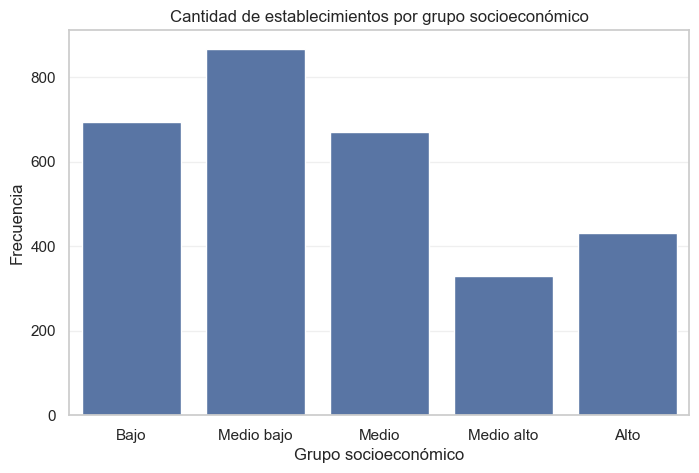

In [30]:
# contar establecimientos en cada grupo socioeconómico
plt.figure(figsize=(8,5))
sns.countplot(data=base_trabajo, x="gse", order=orden_gse)

# detalles del gráfico
plt.title("Cantidad de establecimientos por grupo socioeconómico")
plt.xlabel("Grupo socioeconómico")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.show()

El gráfico muestra cómo se distribuyen los establecimientos según su grupo socioeconómico (GSE).
La mayor cantidad de establecimientos está en:
Medio bajo (el más alto)
luego Bajo y Medio
Los grupos:
Medio alto y Alto
tienen bastante menos establecimientos

La distribución de establecimientos según grupo socioeconómico no es homogénea, observándose una mayor concentración en los niveles bajo y medio bajo, mientras que los grupos medio alto y alto presentan menor cantidad de establecimientos. Esto debe ser considerado en el análisis, ya que podría influir en la interpretación de los resultados si no se comparan adecuadamente los grupos.




### 7.2 Boxplot de lectura por GSE.

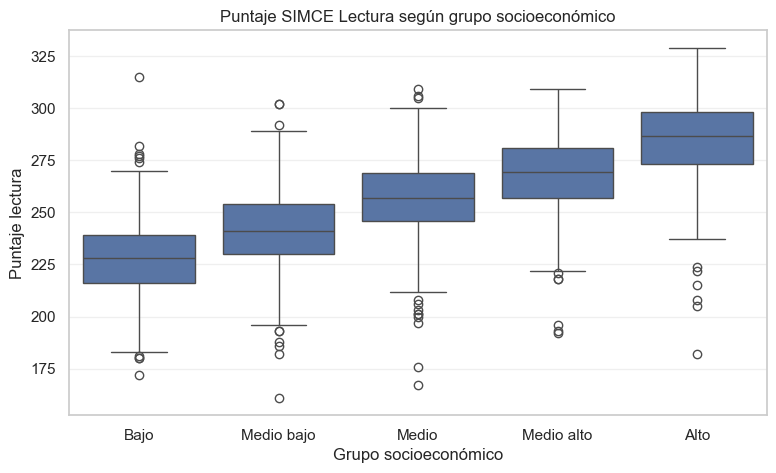

In [31]:
# comparar distribución de lectura entre grupos socioeconómicos
plt.figure(figsize=(9,5))
sns.boxplot(data=base_trabajo, x="gse", y="prom_lect2m_rbd", order=orden_gse)

# detalles del gráfico
plt.title("Puntaje SIMCE Lectura según grupo socioeconómico")
plt.xlabel("Grupo socioeconómico")
plt.ylabel("Puntaje lectura")
plt.grid(axis="y", alpha=0.3)
plt.show()

A medida que aumenta el grupo socioeconómico, aumenta el puntaje SIMCE en lectura.

Se observa una relación positiva clara entre el grupo socioeconómico del establecimiento y el puntaje SIMCE en lectura. A medida que aumenta el nivel socioeconómico, la mediana de los puntajes también aumenta de forma consistente. Esta diferencia entre grupos es significativa, alcanzando aproximadamente 60 puntos entre los niveles más bajo y más alto, lo que sugiere una fuerte asociación entre desigualdad socioeconómica y rendimiento académico.

### 7.3 Boxplot de mátematicas por GSE.

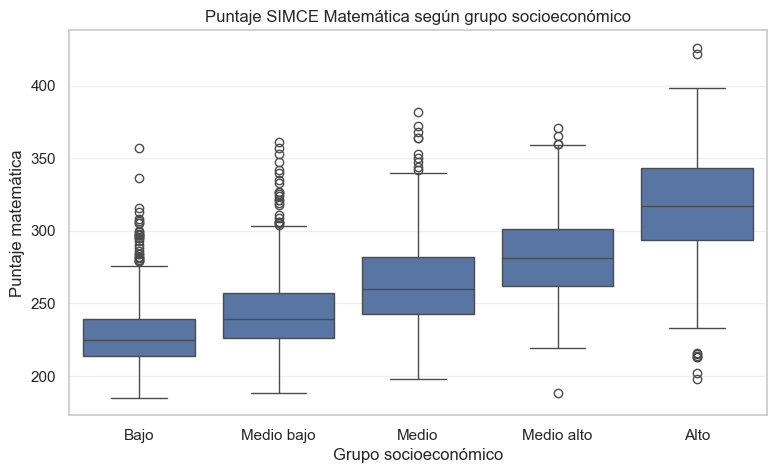

In [32]:
# comparar distribución de matemática entre grupos socioeconómicos
plt.figure(figsize=(9,5))
sns.boxplot(data=base_trabajo, x="gse", y="prom_mate2m_rbd", order=orden_gse)

# detalles del gráfico
plt.title("Puntaje SIMCE Matemática según grupo socioeconómico")
plt.xlabel("Grupo socioeconómico")
plt.ylabel("Puntaje matemática")
plt.grid(axis="y", alpha=0.3)
plt.show()

En el caso de matemática, la relación entre grupo socioeconómico y rendimiento es aún más pronunciada que en lectura. Se observa un aumento progresivo en los puntajes a medida que mejora el nivel socioeconómico del establecimiento, con diferencias cercanas a 90 puntos entre los grupos extremos. Esto sugiere que la desigualdad socioeconómica tiene un impacto relevante en el desempeño académico, particularmente en el área de matemática.

### 7.4 Promedio SIMCE por Grupo.

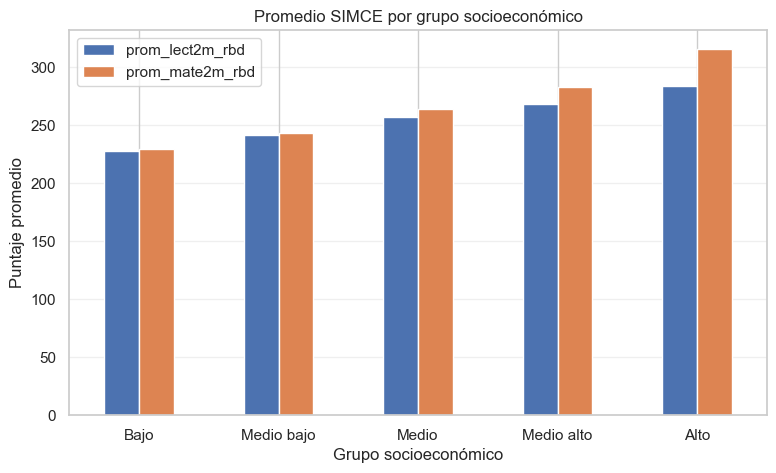

In [33]:
# calcular promedio de lectura y matemática por grupo socioeconómico
tabla_gse = base_trabajo.groupby("gse")[["prom_lect2m_rbd", "prom_mate2m_rbd"]].mean().reindex(orden_gse)

# graficar esos promedios
tabla_gse.plot(kind="bar", figsize=(9,5))
plt.title("Promedio SIMCE por grupo socioeconómico")
plt.xlabel("Grupo socioeconómico")
plt.ylabel("Puntaje promedio")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()

Los resultados muestran un aumento progresivo en los puntajes promedio de SIMCE, tanto en lectura como en matemática, a medida que mejora el grupo socioeconómico del establecimiento. Esta tendencia es consistente en todos los niveles, lo que evidencia una relación sistemática entre desigualdad socioeconómica y rendimiento académico. Además, la brecha entre grupos es mayor en matemática, lo que sugiere que esta área podría ser más sensible a las condiciones del contexto socioeconómico.

### 7.5 Scatter entre IDPS y lectura.

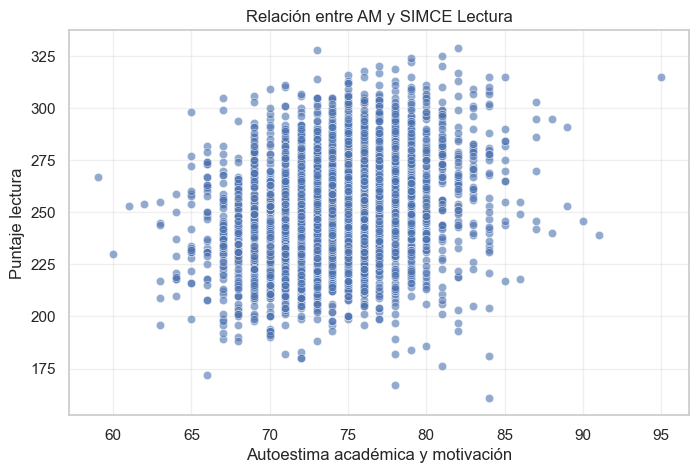

In [34]:
# ver si autoestima académica parece relacionarse con lectura
plt.figure(figsize=(8,5))
sns.scatterplot(data=base_trabajo, x="AM", y="prom_lect2m_rbd", alpha=0.6)

# detalles del gráfico
plt.title("Relación entre AM y SIMCE Lectura")
plt.xlabel("Autoestima académica y motivación")
plt.ylabel("Puntaje lectura")
plt.grid(alpha=0.3)
plt.show()

Se observa una relación positiva leve entre la autoestima académica y el puntaje SIMCE en lectura. Sin embargo, la alta dispersión de los datos indica que esta relación no es fuerte, ya que establecimientos con niveles similares de autoestima presentan resultados académicos muy distintos. Esto sugiere que, si bien la autoestima académica puede influir en el rendimiento, no es un factor determinante por sí solo.

### 7.6 Heatmap de correlaciónes.

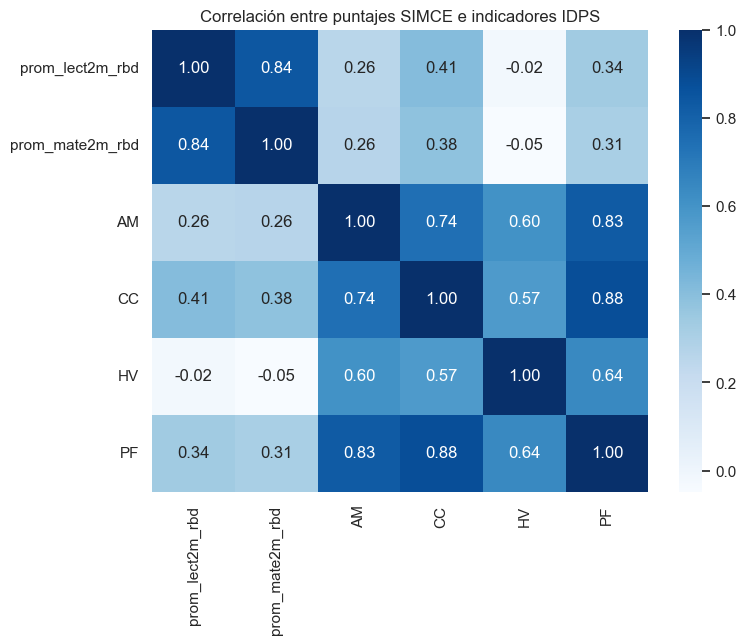

In [35]:
# calcular correlación entre SIMCE e indicadores IDPS
corr = base_trabajo[[
    "prom_lect2m_rbd",
    "prom_mate2m_rbd",
    "AM", "CC", "HV", "PF"
]].corr()

# mostrar matriz en gráfico
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre puntajes SIMCE e indicadores IDPS")
plt.show()

El análisis de correlaciones muestra que los indicadores de desarrollo personal y social presentan relaciones débiles a moderadas con el rendimiento académico medido por SIMCE. En particular, el clima de convivencia escolar presenta la correlación más alta, mientras que los hábitos de vida saludable no muestran relación significativa. En contraste, los puntajes de lectura y matemática presentan una alta correlación entre sí, lo que indica consistencia en el rendimiento académico. Estos resultados sugieren que los factores asociados al contexto socioeconómico podrían tener un mayor impacto en el desempeño académico que los indicadores IDPS.

### 8. Conclusión.

A partir del análisis realizado, se observa una relación clara entre el grupo socioeconómico del establecimiento y el rendimiento académico medido a través de los puntajes SIMCE. Los establecimientos pertenecientes a niveles socioeconómicos más altos presentan consistentemente mejores resultados en lectura y matemática, evidenciando una brecha significativa entre los distintos grupos.

Por otro lado, los indicadores de desarrollo personal y social (IDPS) muestran relaciones débiles a moderadas con el rendimiento académico, siendo el clima de convivencia escolar el indicador más asociado. Sin embargo, su impacto es considerablemente menor en comparación con el grupo socioeconómico.

En conjunto, los resultados sugieren que la desigualdad socioeconómica constituye un factor relevante en el desempeño académico de los estudiantes.

### 9. Respuesta pregunta.

Sí, existe una relación entre la desigualdad socioeconómica y el rendimiento escolar. Los resultados muestran que a medida que aumenta el nivel socioeconómico de los establecimientos, los puntajes SIMCE en lectura y matemática también aumentan de forma consistente. Esta relación es clara y significativa, siendo más fuerte que la observada con los indicadores de desarrollo personal y social.

### 10. Posibles preguntas.

¿Cómo varía el rendimiento académico entre regiones o comunas?